[pystran](https://github.com/PetrKryslUCSD/pystran) - Python package for structural analysis with trusses and beams

(C) 2025-2026, Petr Krysl, pkrysl@ucsd.edu

# Example of a three dimensional frame problem

Last updated: 07/11/26

## Problem description:

Frame with three legs that are clamped, loaded by a torque.

Displacements and internal forces are provided in the book, and we can check
our solution against these reference values.

Important note: Our orientation of the local coordinate system is such that web
of the H-beams is parallel to beam z axis! This is different from the
orientation in the book, where the web is parallel to the y axis.

W8x24 dimensions: height 7.93'', width 6.5'', 
    thickness of flange 0.4'', thickness of web 0.245''

## References

This example is completely solved in the book Matrix Analysis of Structures by
Robert E. Sennett, ISBN 978-1577661436 (Section 6.4).

## Documentation

[pystran docs](https://petrkryslucsd.github.io/pystran)


We begin with the standard imports:

In [87]:
from numpy import array
from numpy.linalg import norm
import context
from pystran import model
from pystran import section
from pystran import plots
from pystran import beam

Important note: Our orientation of the local coordinate system is such that
web of the H-beams is parallel to z axis! This is different from the
orientation in the book, where the web is parallel to the y axis.

Define a few constants:
US customary units, inches, pounds, seconds are assumed.


In [88]:
L = 12 * 15  # Length of the frame legs in inches
E = 29e6
G = 11.15e6
A = 7.08  # W8x24 wide flange
Iz = 18.3
Iy = 82.8
Ix = 83
J = 0.35  # Torsional constant

The loading is a concentrated moment.

In [89]:
M = 41000 * 12  # Applied moment at joint 2 in lb-in

The model is created as three dimensional (3 as argument!).


In [90]:
m = model.create(3)
freedoms = m["freedoms"]

Joints are added at their locations, and the supports of the clamped
joints are specified.


In [92]:
model.add_joint(m, 1, [L, 0.0, L])
model.add_joint(m, 2, [0.0, 0.0, L])
model.add_joint(m, 3, [L, L, L])
model.add_joint(m, 4, [L, 0.0, 0.0])

{'jid': 4, 'coordinates': array([180.,   0.,   0.])}

Only one of the joints is free, the others are clamped.


In [94]:
model.add_support(m["joints"][2], freedoms.ALL_DOFS)
model.add_support(m["joints"][3], freedoms.ALL_DOFS)
model.add_support(m["joints"][4], freedoms.ALL_DOFS)

At this point we can visualize the supports. The translation supports are
shown with arrow heads.


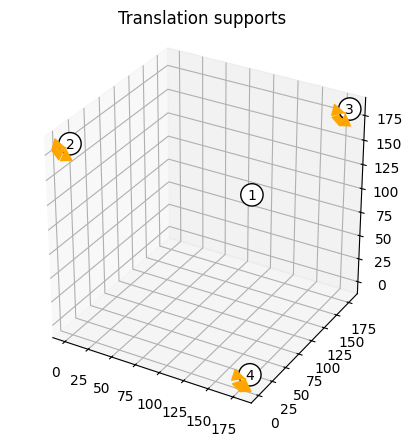

In [96]:
ax = plots.setup(m)
plots.plot_joint_ids(m)
plots.plot_translation_supports(m)
ax.set_title("Translation supports")
plots.show(m)

The rotation supports are shown next.


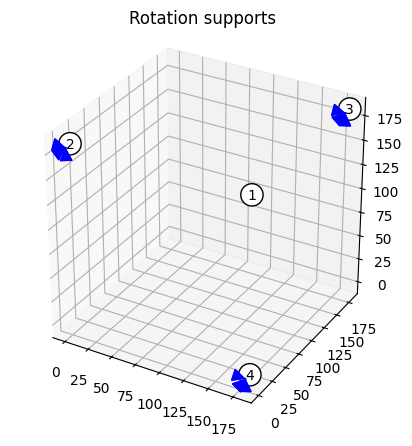

In [98]:
ax = plots.setup(m)
plots.plot_joint_ids(m)
plots.plot_rotation_supports(m)
ax.set_title("Rotation supports")
plots.show(m)

There are three beams. The cross sectional properties are the same, but the
beams have different orientation of their local coordinate systems in space.
Therefore, we create two sections. The first section (for beams 1 and 2)
orients the beam local coordinate system such that the x-z planes contains
the vector [0, 0, 1].

In [99]:
xz_vector = [0, 0, 1]
sect_12 = section.beam_3d_section(
    "sect_12", E=E, G=G, A=A, Ix=Ix, Iy=Iy, Iz=Iz, J=J, xz_vector=xz_vector
)

The third beam is parallel to [0, 0, 1]. Therefore the orientation of the
local coordinate system needs to be expressed with a different vector. The
easiest choice is to use the vector [1, 0, 0].


In [100]:
xz_vector = [1, 0, 0]
sect_3 = section.beam_3d_section(
    "sect_3", E=E, G=G, A=A, Ix=Ix, Iy=Iy, Iz=Iz, J=J, xz_vector=xz_vector
)

With the above definitions of the sections at hand, we define the three
members.

In [101]:
model.add_beam_member(m, 1, [1, 2], sect_12)
model.add_beam_member(m, 2, [3, 1], sect_12)
model.add_beam_member(m, 3, [1, 4], sect_3)

{'mid': 3,
 'connectivity': [1, 4],
 'section': {'name': 'sect_3',
  'E': 29000000.0,
  'G': 11150000.0,
  'rho': 0.0,
  'CTE': 0.0,
  'A': 7.08,
  'Ix': 83,
  'Iy': 82.8,
  'Iz': 18.3,
  'J': 0.35,
  'xy_vector': None,
  'xz_vector': array([1, 0, 0])}}

This plot shows the orientations of the local coordinate systems of the
beams.


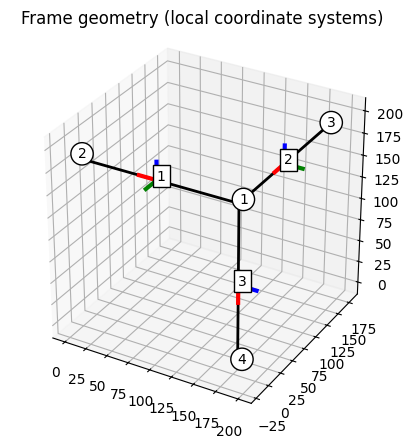

In [102]:
ax = plots.setup(m)
plots.plot_joint_ids(m)
plots.plot_members(m)
plots.plot_member_ids(m)
plots.plot_member_orientation(m, 20)
ax.set_title("Frame geometry (local coordinate systems)")
plots.show(m)

Next we add the applied moment, and


In [103]:
model.add_load(m["joints"][1], freedoms.UR2, M)

we can render the applied moment:

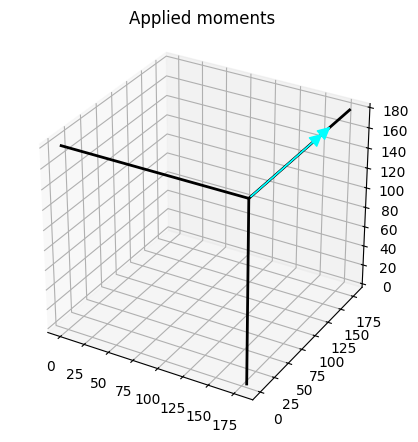

In [104]:
ax = plots.setup(m)
plots.plot_members(m)
ax = plots.plot_applied_moments(m, 0.0003)
ax.set_title("Applied moments")
plots.show(m)

Now we can solve the static equilibrium of the frame.


In [105]:
model.number_dofs(m)
model.solve_statics(m)

The displacements of the joints can be printed out. Recall that joints 3 and
4 are clamped, and their displacements are therefore zero.


In [106]:
for jid in [1]:
    j = m["joints"][jid]
    print(jid, j["displacements"])

1 [ 1.79380884e-03 -4.09369624e-07 -1.79189574e-03  1.22261046e-05
  4.62419592e-03  7.46563548e-06]


These are the displacements of joint 1 consistent with the referenced book:


In [107]:
ref1 = [
    1.79380884e-03,
    -4.09369624e-07,
    -1.79189574e-03,
    1.22261046e-05,
    4.62419592e-03,
    7.46563548e-06,
]
if norm(m["joints"][1]["displacements"] - ref1) > 1.0e-1 * norm(ref1):
    raise ValueError("Displacement calculation error")

The internal forces in the members can be calculated. Here we report the "end
forces", i.e., the forces and moments at the ends of the members that act on
the joints.


In [108]:
for k in m["beam_members"].keys():
    member = m["beam_members"][k]
    connectivity = member["connectivity"]
    i, j = m["joints"][connectivity[0]], m["joints"][connectivity[1]]
    f = beam.beam_3d_end_forces(member, i, j)
    print(f"Member {k}: ")
    print(f"   Joint {connectivity[0]}: ")
    print(f"   N={f['Ni']:.5}, Qy={f['Qyi']:.5}, Qz={f['Qzi']:.5}")
    print(f"   T={f['Ti']:.5}, My={f['Myi']:.5}, Mz={f['Mzi']:.5}")
    print(f"   Joint {connectivity[1]}: ")
    print(f"   N={f['Nj']:.5}, Qy={f['Qyj']:.5}, Qz={f['Qzj']:.5}")
    print(f"   T={f['Tj']:.5}, My={f['Myj']:.5}, Mz={f['Mzj']:.5}")

Member 1: 
   Joint 1: 
   N=2046.1, Qy=-0.73415, Qz=-2047.4
   T=0.26507, My=2.4595e+05, Mz=-88.085
   Joint 2: 
   N=-2046.1, Qy=0.73415, Qz=2047.4
   T=-0.26507, My=1.2258e+05, Mz=-44.063
Member 2: 
   Joint 3: 
   N=0.46695, Qy=1.2251, Qz=-3.4168
   T=-100.26, My=470.6, Mz=132.27
   Joint 1: 
   N=-0.46695, Qy=-1.2251, Qz=3.4168
   T=100.26, My=144.41, Mz=88.247
Member 3: 
   Joint 1: 
   N=-2044.0, Qy=-1.2011, Qz=2047.4
   T=0.16186, My=-2.4595e+05, Mz=-144.15
   Joint 4: 
   N=2044.0, Qy=1.2011, Qz=-2047.4
   T=-0.16186, My=-1.2258e+05, Mz=-72.053


Let us compare to the reference values: Member 1, 
joint at the start of the member.


In [109]:
member = m["beam_members"][1]
connectivity = member["connectivity"]
i, j = m["joints"][connectivity[0]], m["joints"][connectivity[1]]
f = beam.beam_3d_end_forces(member, i, j)
if abs(f["Ni"] - 2046) / 2046 > 1e-2:
    raise ValueError("Member 1, joint i, axial force error")
if abs(f["Qyi"] - -0.73) / 0.73 > 1e-2:
    raise ValueError("Member 1, joint i, shear force error")
if abs(f["Qzi"] - -2047) / 2047 > 1e-2:
    raise ValueError("Member 1, joint i, shear force error")
if abs(f["Ti"] - 0.27) / 0.27 > 2e-2:
    raise ValueError("Member 1, joint i, torsion moment error")
if abs(f["Myi"] - 245950) / 245950 > 1e-2:
    raise ValueError("Member 1, joint i, bending moment error")
if abs(f["Mzi"] - -88) / 88 > 1e-2:
    raise ValueError("Member 1, joint i, bending moment error")

The solution to the problem can be visualized with a number of plots. We start
with the deformed shape of the frame.


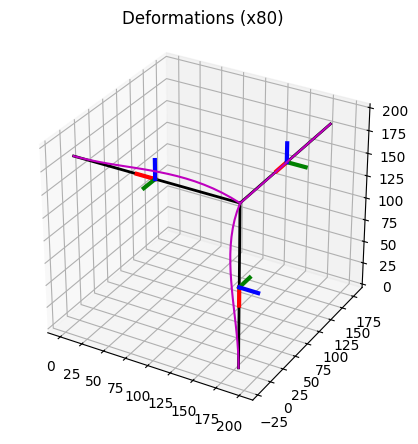

In [110]:
ax = plots.setup(m)
plots.plot_members(m)
plots.plot_member_orientation(m, 20)
ax = plots.plot_deformations(m, 80.0)
ax.set_title("Deformations (x80)")
plots.show(m)

The shear forces in the members can be visualized with diagrams.
For instance, the shear forces along the z-axis are shown.
Note that the shear forces are plotted in the plane
in which they act.


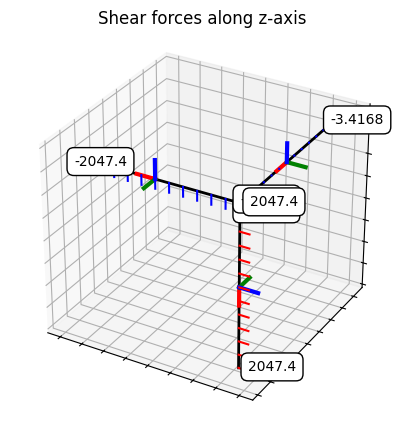

In [111]:
ax = plots.setup(m)
plots.plot_members(m)
plots.plot_member_orientation(m, 20)
ax = plots.plot_shear_forces(m, scale=0.0050)
ax.set_title("Shear forces along z-axis")
plots.show(m)

Analogous diagrams can be produced for the torsional moments in the members.
The torsional moments are plotted in a local plane of the beam, but of course
they are axial.


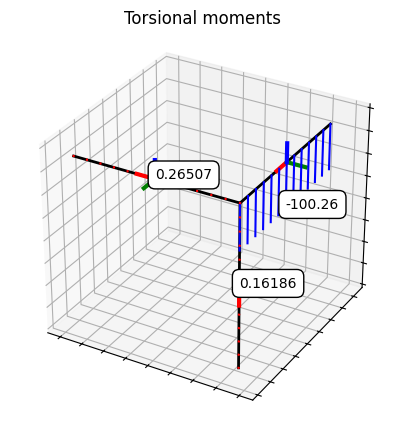

In [112]:
ax = plots.setup(m)
plots.plot_members(m)
plots.plot_member_orientation(m, 20)
ax = plots.plot_torsion_moments(m, scale=0.5)
ax.set_title("Torsional moments")
plots.show(m)

Finally, the axial forces in the members can be visualized. The axial forces
are by definition along the axis of the beam, but they are plotted orthogonal
to the axis in one of the coordinate planes of the beam.


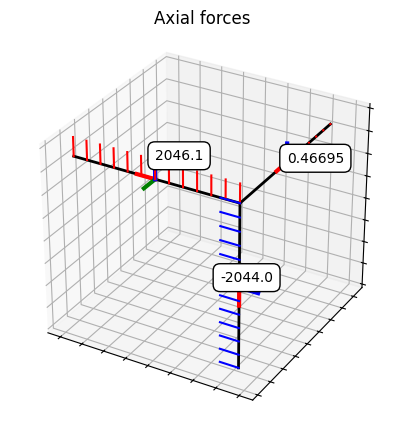

In [113]:
ax = plots.setup(m)
plots.plot_members(m)
plots.plot_member_orientation(m, 20)
ax = plots.plot_axial_forces(m, scale=0.01)
ax.set_title("Axial forces")
plots.show(m)